In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/'

In [3]:
adata_pt02 = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/adata_zones_broad_celltypes_zones_highsen_pt02_neighbor.h5ad')

In [4]:
adata_pt02 

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [5]:
adata_heps = adata_pt02[adata_pt02.obs['pred_cell_types'].isin(['Hepatocytes'])]

In [6]:
adata_heps

View of AnnData object with n_obs × n_vars = 178400 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [7]:
adata_heps.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [8]:
adata_heps.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes    178400
Name: count, dtype: int64

In [9]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted2 = adata_heps[
    adata_heps.obs.sort_values(by="celltype_proj_heps_pt02", key=lambda x: x != target_celltype, 
                               ascending = False).index
]


In [10]:
neon_palette = {
    "Hepatocytes.Zone2": "#f2f2f2",         # Neon Deep Sky Blue
    "Hepatocytes.Zone3": "#f2f2f2",         # Neon Gold Yellow
    "Hepatocytes.Senescent": "#f2f2f2",     # Neon Orange-Red
    "Hepatocytes.Senescent.High": "#FF4500",     # Neon Orange-Red
    "Hepatocytes.Zone1": "#f2f2f2",         # Neon Deep Pink
    "Myeloid": "#f2f2f2",                   # Neon Blue
    "Endothelial": "#f2f2f2",               # Neon Purple
    "HSC": "#f2f2f2",                       # Neon Cyan
    "Cholangiocyte": "#f2f2f2",             # Neon Green
    "B": "#f2f2f2",                         # Neon Orange
    "T_NK": "#f2f2f2",                      # Neon Yellow
}

# Convert to a ListedColormap
#neon_cmap = mcolors.ListedColormap(list(neon_palette.values()), name="neon_cmap")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


[<Axes: title={'center': 'celltype_proj_heps_pt02'}, xlabel='spatial1', ylabel='spatial2'>]

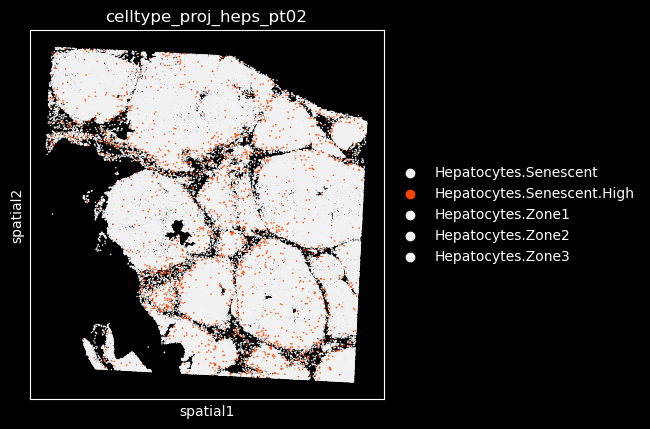

In [11]:
plt.style.use('dark_background')
sc.pl.spatial(
    adata_sorted2, 
    color='celltype_proj_heps_pt02',
    palette=neon_palette, 
    show=False, 
    size=4, 
    img_key=None,
)
#plt.savefig(f"{odir}pt02_high_sen_cells.pdf")

In [12]:
adata_heps_sen_high = adata_heps[adata_heps.obs['celltype_proj_heps_pt02'].isin(['Hepatocytes.Senescent.High'])]

In [13]:
#FFCC00

neon_palette_gold = {
    "Hepatocytes.Zone2": "#f2f2f2",         # Neon Deep Sky Blue
    "Hepatocytes.Zone3": "#f2f2f2",         # Neon Gold Yellow
    "Hepatocytes.Senescent": "#f2f2f2",     # Neon Orange-Red
    "Hepatocytes.Senescent.High": "#FFCC00",     # Neon Orange-Red
    "Hepatocytes.Zone1": "#f2f2f2",         # Neon Deep Pink
    "Myeloid": "#f2f2f2",                   # Neon Blue
    "Endothelial": "#f2f2f2",               # Neon Purple
    "HSC": "#f2f2f2",                       # Neon Cyan
    "Cholangiocyte": "#f2f2f2",             # Neon Green
    "B": "#f2f2f2",                         # Neon Orange
    "T_NK": "#f2f2f2",                      # Neon Yellow
}

# Convert to a ListedColormap
#neon_cmap = mcolors.ListedColormap(list(neon_palette.values()), name="neon_cmap")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


[<Axes: title={'center': 'celltype_proj_heps_pt02'}, xlabel='spatial1', ylabel='spatial2'>]

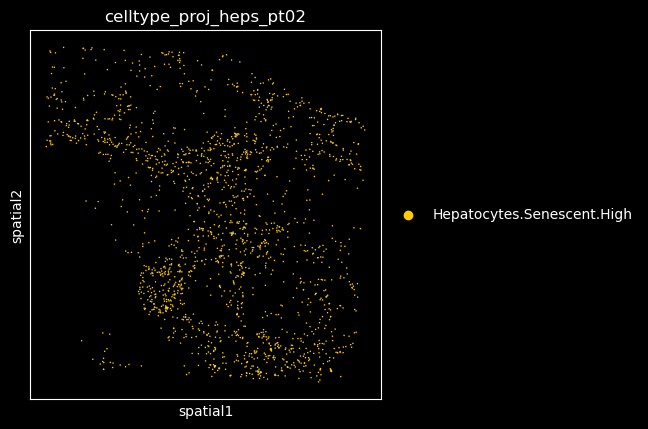

In [14]:
plt.style.use('dark_background')
sc.pl.spatial(
    adata_heps_sen_high, 
    color='celltype_proj_heps_pt02',
    palette=neon_palette_gold, 
    show=False, 
    size=4, 
    img_key=None,
)
#plt.savefig(f"{odir}pt02_high_sen_cells_only.pdf")

In [15]:
adata_pt02.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [16]:
# make hepatocytes one color orange
# make hep.sen.high one color blue
# make all other broad celltypes one color green

# #25fbfd cyan

In [17]:
neon_palette_three = {
    "Hepatocytes.Zone2": "#FF007F",         # Neon Deep Sky Blue
    "Hepatocytes.Zone3": "#FF007F",         # Neon Gold Yellow
    "Hepatocytes.Senescent": "#FF007F",     # Neon Orange-Red
    #"Hepatocytes.Senescent.High": "#31bde1",     # cellranger cyan
    "Hepatocytes.Senescent.High": "#00FF00",     # Neon cyan

    "Hepatocytes.Zone1": "#FF007F",         # Neon Deep Pink
    "Myeloid": "#FF8800",                   # Neon Blue
    "Endothelial": "#FF8800",               # Neon Purple
    "HSC": "#FF8800",                       # Neon Cyan
    "Cholangiocyte": "#FF8800",             # Neon Green
    "B": "#FF8800",                         # Neon Orange
    "T_NK": "#FF8800",                      # Neon Yellow

    #FF8800 - orange
    #00FF00- neon green
}

# Convert to a ListedColormap
#neon_cmap = mcolors.ListedColormap(list(neon_palette.values()), name="neon_cmap")

In [ ]:
# grapefruit palette
# heps pink #FF007F
# non heps neon orange "#FF8800
# sen high neon green neon green #00FF00

In [ ]:
# spaceranger colors
# blue #31bde1
# neon green #a4fb3b
# orange #e78538

In [73]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted2 = adata_pt02[
    adata_pt02.obs.sort_values(by="celltype_proj_heps_pt02", key=lambda x: x != target_celltype, 
                               ascending = False).index
]


In [74]:
adata_pt02.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [75]:
adata_pt02

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'celltype_proj_heps_pt02_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [76]:
adata_sorted2

View of AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'celltype_proj_heps_pt02_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [77]:
adata_sorted2.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


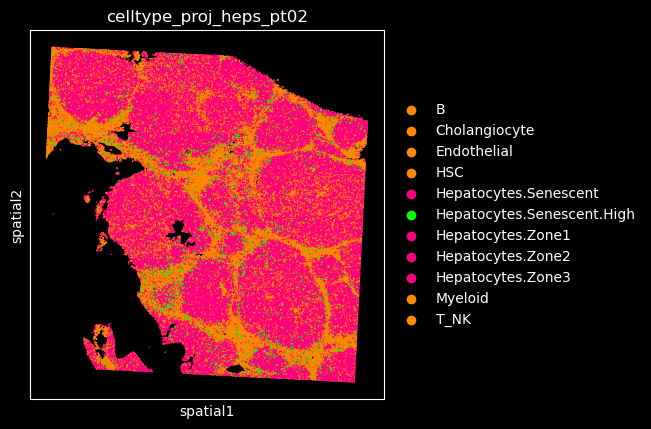

In [78]:
plt.style.use('dark_background')
sc.pl.spatial(
    adata_sorted2, 
    color='celltype_proj_heps_pt02',
    palette=neon_palette_three, 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}pt02_high_sen_cells_three_col.pdf")

In [57]:
# from paper very original
neon_rainbow_colors_broad = {
        'Hepatocytes': '#FF007F',    # Neon pink #maroon is '#800000'
        'Myeloid': '#0000FF',           # Neon blue
        'T_NK': '#FFFA00',              # Neon yellow
        'Cholangiocyte': '#00FF00',  # Neon green
        'HSC': '#00FFFF',            # Neon cyan
        'Mast': '#FF1900',        # Neon red
        'Endothelial': '#8A2BE2',    # Neon purple
        'Schwann': '#FF1493',        # Neon deep pink
        'NK': '#FFFDBB',             # lighter yellow
        'B': '#FF8800'               # Neon hot pink
    }

In [ ]:
# dark purple #341539

In [18]:
neon_palette_three = {
    "Hepatocytes.Zone2": "#FF007F",         # Neon Deep Sky Blue
    "Hepatocytes.Zone3": "#FF007F",         # Neon Gold Yellow
    "Hepatocytes.Senescent": "#FF007F",     # Neon Orange-Red
    #"Hepatocytes.Senescent.High": "#31bde1",     # cellranger cyan
    "Hepatocytes.Senescent.High": "#00FF00",     # Neon cyan

    "Hepatocytes.Zone1": "#FF007F",         # Neon Deep Pink
    "Myeloid": "#341539",                   # Neon Blue
    "Endothelial": "#341539",               # Neon Purple
    "HSC": "#341539",                       # Neon Cyan
    "Cholangiocyte": "#341539",             # Neon Green
    "B": "#341539",                         # Neon Orange
    "T_NK": "#341539",                      # Neon Yellow

    #FF8800 - orange
    #00FF00- neon green
}

# Convert to a ListedColormap
#neon_cmap = mcolors.ListedColormap(list(neon_palette.values()), name="neon_cmap")

In [19]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted2 = adata_pt02[
    adata_pt02.obs.sort_values(by="celltype_proj_heps_pt02", key=lambda x: x != target_celltype, 
                               ascending = False).index
]


/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


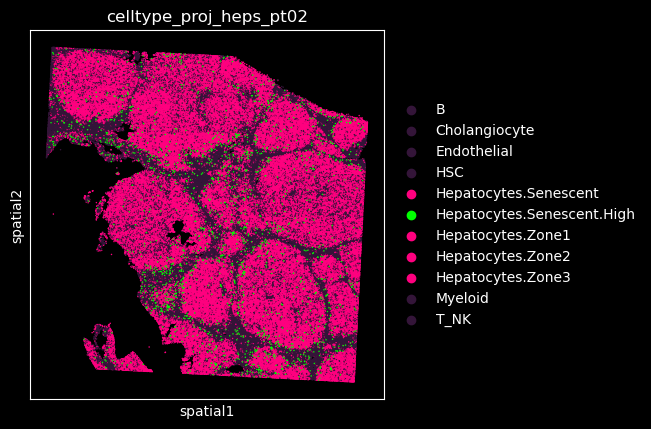

In [20]:
plt.style.use('dark_background')
sc.pl.spatial(
    adata_sorted2, 
    color='celltype_proj_heps_pt02',
    palette=neon_palette_three, 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}pt02_high_sen_cells_three_col_test.pdf")

In [78]:
neon_palette_three = {
    "Hepatocytes.Zone2": "#c32148",         # Neon Deep Sky Blue
    "Hepatocytes.Zone3": "#c32148",         # Neon Gold Yellow
    "Hepatocytes.Senescent": "#c32148",     # Neon Orange-Red
    #"Hepatocytes.Senescent.High": "#31bde1",     # cellranger cyan
    "Hepatocytes.Senescent.High": "#00FF00",     # Neon cyan

    "Hepatocytes.Zone1": "#c32148",         # Neon Deep Pink
    "Myeloid": "#051094",                   # Neon Blue
    "Endothelial": "#051094",               # Neon Purple
    "HSC": "#051094",                       # Neon Cyan
    "Cholangiocyte": "#051094",             # Neon Green
    "B": "#051094",                         # Neon Orange
    "T_NK": "#051094",                      # Neon Yellow

    #FF8800 - orange
    #00FF00- neon green
}

# Convert to a ListedColormap
#neon_cmap = mcolors.ListedColormap(list(neon_palette.values()), name="neon_cmap")

In [75]:
# original neon pink #FF007F
# burgundy #660033
# maroon pink b03060
# bright maroon c32148

# first #341539 dark purple
# two  4b0082 indigo too bright
# three 743089 luxury purple
# four 000080 navy blue
# five 000435 dark navy
# six 051094 admiral

In [79]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted2 = adata_pt02[
    adata_pt02.obs.sort_values(by="celltype_proj_heps_pt02", key=lambda x: x != target_celltype, 
                               ascending = False).index
]


/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


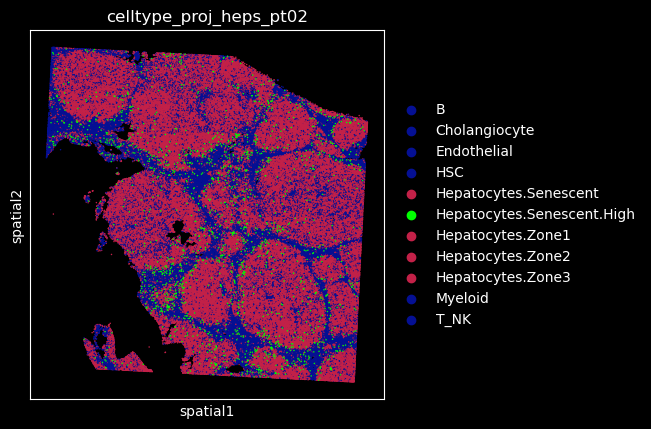

In [80]:
plt.style.use('dark_background')
sc.pl.spatial(
    adata_sorted2, 
    color='celltype_proj_heps_pt02',
    palette=neon_palette_three, 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}pt02_high_sen_cells_three_col_test.pdf")